In [4]:
!pip install google-play-scraper

import pandas as pd
from google_play_scraper import Sort, reviews

# Google Play Store app ID for M-Paspor
app_id = 'id.go.imigrasi.paspor_online'

# Fetch reviews (e.g., 200 reviews)
result, continuation_token = reviews(
    app_id,
    lang='id', # Language for reviews
    country='id', # Country for reviews
    sort=Sort.NEWEST, # Sort by newest reviews
    count=200 # Number of reviews to fetch
)

# Convert to DataFrame
df_gplay = pd.DataFrame(result)

# 'content' for review text, 'score' for rating, 'at' for date
df_gplay = df_gplay[['content', 'score', 'at']]
df_gplay.columns = ['content', 'score', 'date']

df_gplay.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00


,content,score,date
0,butuh pembaruan terus bilangnya tapi apk aja b...,1,2026-04-15 03:04:16
1,cukup mudah...,5,2026-04-15 01:02:35
2,seperti pengalaman bintang 1 sebelum sebelumny...,1,2026-04-15 00:11:43
3,"kenapa pada kasih rating bintang 1 sih, padaha...",5,2026-04-14 05:33:59
4,apk m passport sedang error kah admin?,5,2026-04-14 01:40:23


### Informasi Dataset

In [5]:
print('Informasi Umum DataFrame:')
df_gplay.info()

print('\nStatistik Deskriptif DataFrame:')
display(df_gplay.describe(include='all'))

Informasi Umum DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   content  200 non-null    object        
 1   score    200 non-null    int64         
 2   date     200 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.8+ KB

Statistik Deskriptif DataFrame:


,content,score,date
count,200,200.000000,200
unique,196,NaN,NaN
top,ok,NaN,NaN
freq,3,NaN,NaN
mean,NaN,2.125000,2026-03-23 15:58:11.400000256
min,NaN,1.000000,2026-02-18 13:06:15
25%,NaN,1.000000,2026-03-12 07:01:07.500000
50%,NaN,1.000000,2026-03-26 11:30:24
75%,NaN,3.000000,2026-04-04 02:36:04.500000
max,NaN,5.000000,2026-04-15 03:04:16


In [6]:
def label_sentimen(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

df_gplay['label'] = df_gplay['score'].apply(label_sentimen)

display(df_gplay.head())

,content,score,date,label
0,butuh pembaruan terus bilangnya tapi apk aja b...,1,2026-04-15 03:04:16,negatif
1,cukup mudah...,5,2026-04-15 01:02:35,positif
2,seperti pengalaman bintang 1 sebelum sebelumny...,1,2026-04-15 00:11:43,negatif
3,"kenapa pada kasih rating bintang 1 sih, padaha...",5,2026-04-14 05:33:59,positif
4,apk m passport sedang error kah admin?,5,2026-04-14 01:40:23,positif


### 2️⃣ Preprocessing teks

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df_gplay['clean_text'] = df_gplay['content'].apply(clean_text)

display(df_gplay.head())

,content,score,date,label,clean_text
0,butuh pembaruan terus bilangnya tapi apk aja b...,1,2026-04-15 03:04:16,negatif,butuh pembaruan terus bilangnya tapi apk aja b...
1,cukup mudah...,5,2026-04-15 01:02:35,positif,cukup mudah
2,seperti pengalaman bintang 1 sebelum sebelumny...,1,2026-04-15 00:11:43,negatif,seperti pengalaman bintang sebelum sebelumnya...
3,"kenapa pada kasih rating bintang 1 sih, padaha...",5,2026-04-14 05:33:59,positif,kenapa pada kasih rating bintang sih padahala...
4,apk m passport sedang error kah admin?,5,2026-04-14 01:40:23,positif,apk m passport sedang error kah admin


### 3️⃣ TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100)
X = tfidf.fit_transform(df_gplay['clean_text'])
y = df_gplay['label']

### 4️⃣ Split data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 5️⃣ Model (Naive Bayes)

In [10]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

### 6️⃣ Evaluasi

In [11]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8
              precision    recall  f1-score   support

     negatif       0.77      1.00      0.87        27
      netral       0.00      0.00      0.00         3
     positif       1.00      0.50      0.67        10

    accuracy                           0.80        40
   macro avg       0.59      0.50      0.51        40
weighted avg       0.77      0.80      0.75        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 7️⃣ Visualisasi

/tmp/ipykernel_10365/2354431373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_gplay, palette='viridis')


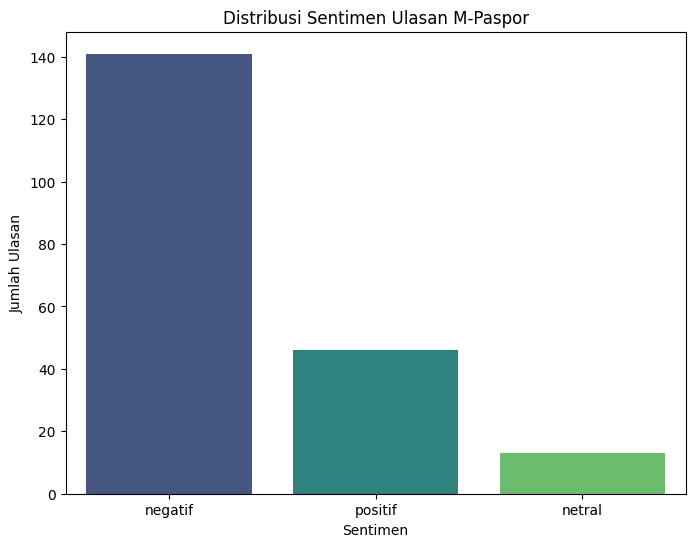

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart for sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df_gplay, palette='viridis')
plt.title('Distribusi Sentimen Ulasan M-Paspor')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

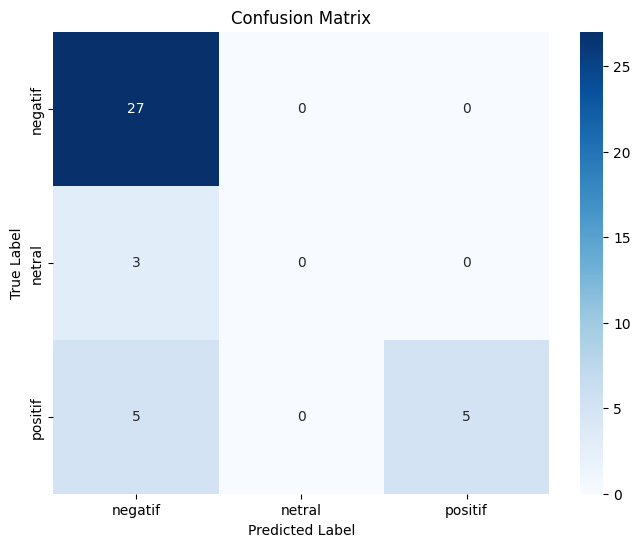

In [13]:
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Wordcloud / Top Words

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


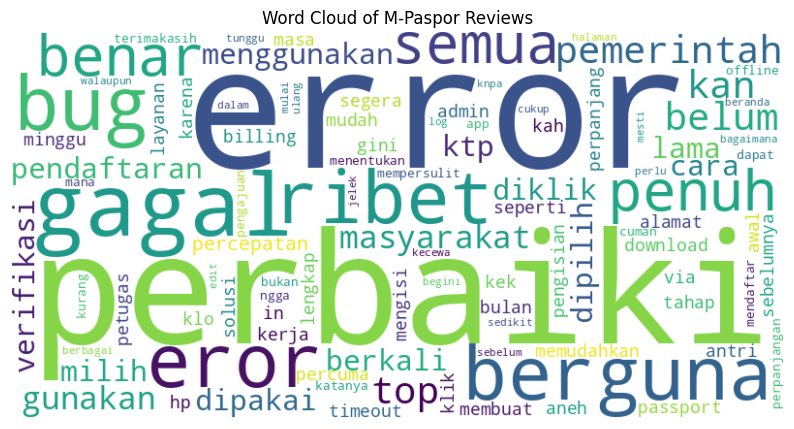

In [16]:
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter

nltk.download('punkt') # Added to download the missing NLTK resource
nltk.download('punkt_tab') # Explicitly download punkt_tab as suggested by error

# Base custom stopwords provided by the user
base_stop_words = set([
    'di', 'nya', 'dan', 'ini', 'saya', 'aku', 'gua', 'gw', 'gue', 'bisa', 'ya', 'malah', 'kenapa',
    'pada', 'lagi', 'dari', 'baru', 'itu', 'ada', 'negara', 'selalu', 'buat', 'tapi', 'jangab',
    'udah', 'terus', 'ga bisa', 'tolong', 'bayar', 'gabisa', 'tolong dong', 'baik', 'apk',
    'm-paspor', 'paspor', 'sudah', 'malah', 'giliran', 'mau', 'jamm', 'pas',
    'ku', 'pak', 'cek', 'dlaam', 'sy', 'beberapa', 'ketika', 'proses', 'karna', 'yaa', 'mungkin', 'dah',
    'sepertinya', 'dekat', 'nunggu', 'kapan', 'masyarakan', 'apknya', 'mohon', 'dikirim', 'keluarga'
])

target_words = ['error', 'gagal', 'ribet', 'eror', 'perbaiki', 'aneh', 'bug', 'mempersulit', 'masalah', 'lama', 'kecewa', 'berguna', 'memudahkan']

all_text_original = ' '.join(df_gplay['clean_text'])

words_raw = word_tokenize(all_text_original)
raw_word_freq = Counter(words_raw)

dynamic_stopwords = set()
for word, freq in raw_word_freq.most_common(150):
    if word not in target_words and word not in base_stop_words:
        dynamic_stopwords.add(word)
final_stopwords = base_stop_words.union(dynamic_stopwords)

all_text_for_wordcloud = all_text_original

wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=final_stopwords, max_words=100).generate(all_text_for_wordcloud)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of M-Paspor Reviews')
plt.show()

In [ ]:
df_gplay.to_csv('m-paspor_google_play_reviews.csv', index=False)
print('File saved as m-paspor_google_play_reviews.csv')

In [ ]:
from google.colab import files
files.download('m-paspor_google_play_reviews.csv')